# Ejemplo para adquirir de las plantas virtualizadas

Como se usa mqtt, se deben actualizar las dependencias:

``` pip install paho-mqtt ```

In [25]:
import time
import threading
import matplotlib.pyplot as plt
import paho.mqtt.client as mqtt
import json
import numpy as np


## Parámetros

Suponiendo que nos conectamos a la planta 1

In [27]:
broker = "000ea79fd6784cbb9ad2c51d6bbcbf60.s1.eu.hivemq.cloud"
port = 8883

username = "ica_tps"
password = "fiuba2026"

topic_medida = "planta1/medida"
topic_u = "planta1/u"
topic_d = "planta1/Fin"

tiempo = []
datos = []
entrada = []
t_planta = None

## Callback

In [28]:
def on_connect(client, userdata, flags, rc):

    if rc == 0:
        print("MQTT conectado")

        client.subscribe(topic_medida)

    else:
        print("Error MQTT:", rc)


def on_message(client, userdata, msg):

    if msg.topic == topic_medida :                 
        dato = json.loads(msg.payload.decode())

        tiempo.append(dato["t"] / 1000.0)   # ms -> s
        datos.append(dato["y"])
        entrada.append(dato["u"])


## Conexión

In [29]:
client = mqtt.Client()

client.username_pw_set(
    username,
    password
)

client.tls_set()

client.on_connect = on_connect
client.on_message = on_message

client.connect(
    broker,
    port
)

client.loop_start()

/tmp/ipykernel_96417/2016047778.py:1: DeprecationWarning: Callback API version 1 is deprecated, update to latest version
  client = mqtt.Client()


<MQTTErrorCode.MQTT_ERR_SUCCESS: 0>

MQTT conectado


## Adquisición durante 1 minuto

Apertura de la válvula (%): u = 20
Valor de caudal de entrada (m3/s): d = 0.0035
Adquiriendo datos durante 60 seg...
Fin adquisición
Muestras recibidas: 150


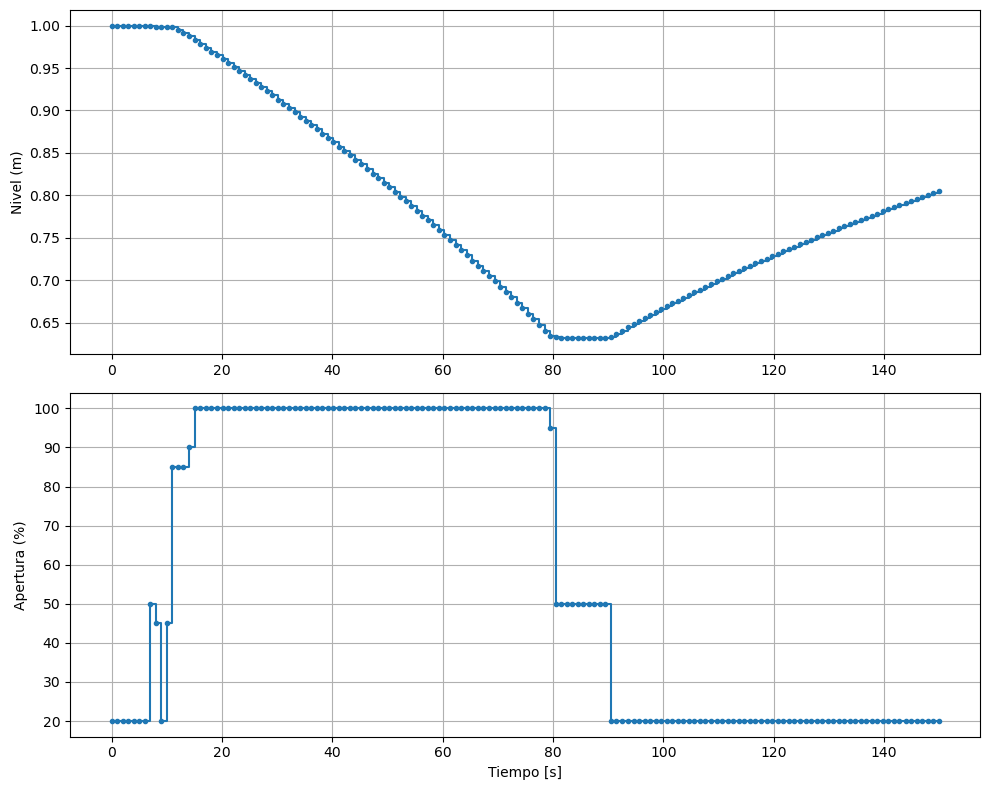

In [30]:
# Escalón en la actuación
u_escalon = 20
msg = client.publish(
    topic_u,
    str(u_escalon),
    retain = False
)
msg.wait_for_publish()
print("Apertura de la válvula (%): u =", u_escalon)

# Escalón en la perturbación
d_escalon = 0.0035
msg = client.publish(
    topic_d,
    str(d_escalon),
    retain=True
)
msg.wait_for_publish()
print("Valor de caudal de entrada (m3/s): d =", d_escalon)

duracion = 60   # segundos de adquisición
print(f"Adquiriendo datos durante {duracion} seg...")
time.sleep(duracion)

client.loop_stop()
client.disconnect()

print("Fin adquisición")
print("Muestras recibidas:", len(datos))


plt.figure(figsize=(10,8))
plt.subplot(2,1,1)
plt.step(np.array(tiempo)-tiempo[0], datos, '.-', where='post')
plt.ylabel("Nivel (m)")
plt.grid()
plt.subplot(2,1,2)
plt.step(np.array(tiempo)-tiempo[0], entrada, '.-', where='post')
plt.xlabel("Tiempo [s]")
plt.ylabel("Apertura (%)")
plt.grid()
plt.tight_layout()
plt.show()